# Customer Churn Pattern Analysis

## Project Overview
This notebook analyzes customer-level telecom data to identify patterns associated with churn. The workflow focuses on churn distribution, feature relationships, risk-factor segmentation, and business actions that could reduce avoidable churn.

## Learning Objectives
- Understand how churn is distributed across the customer base.
- Compare churned and retained customers across demographic, contract, service, and billing features.
- Build risk-focused customer segments instead of relying on one-variable summaries.
- Translate descriptive churn analysis into practical retention recommendations.

## Business / Research Problem
Customer churn directly reduces recurring revenue and increases acquisition pressure. A business needs to know which customer profiles are most at risk, which service or pricing patterns are associated with churn, and where retention efforts are most likely to pay off.

## Why This Analysis Matters
Retaining an existing customer is usually cheaper than replacing one. A clear view of churn patterns helps teams prioritize contract design, support interventions, pricing changes, and offer strategy more effectively.

## Dataset OverviewThis notebook uses the repo-local telecom churn dataset at `data/customer_churn_telecom/telecom_customer_churn.csv`. The verified schema includes demographic fields, contract and service information, billing variables, revenue measures, and churn-related fields such as `Customer Status`, `Churn Category`, and `Churn Reason`.## Dataset Source and License NotesThe dataset is loaded from a repo-local CSV already present in this workspace. Verify the redistribution and external-use license of the source copy you rely on outside this repository.The `Customer Status` column has three states in this dataset: `Stayed`, `Churned`, and `Joined`. For churn pattern analysis, this notebook compares `Stayed` and `Churned` customers directly and keeps `Joined` visible in overall status reporting but out of the main churn-risk comparison to avoid mixing new customers with established retention outcomes.

## Environment Setup
The next cell installs only the packages needed for this notebook so the analysis can be rerun in a clean environment without hidden setup assumptions.

In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

for package_name, import_name in REQUIRED_PACKAGES.items():
    ensure_package(package_name, import_name)

print("Environment setup complete.")

Environment setup complete.


## Imports
These imports support data loading, cleaning, summarization, and visualization. The notebook keeps its dependency surface intentionally small.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
np.random.seed(42)

## Configuration / Constants
This block locates the dataset, defines the expected schema, and makes the main notebook assumptions explicit. Keeping these in one place makes the analysis easier to review later.

In [3]:
def locate_workspace_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "README.md").exists():
            return candidate
    return start_path

WORKSPACE_ROOT = locate_workspace_root(Path.cwd())
DATASET_PATH = WORKSPACE_ROOT / "data" / "customer_churn_telecom" / "telecom_customer_churn.csv"
EXPECTED_COLUMNS = [
    "Customer ID", "Gender", "Age", "Married", "Number of Dependents", "City", "Zip Code",
    "Latitude", "Longitude", "Number of Referrals", "Tenure in Months", "Offer", "Phone Service",
    "Avg Monthly Long Distance Charges", "Multiple Lines", "Internet Service", "Internet Type",
    "Avg Monthly GB Download", "Online Security", "Online Backup", "Device Protection Plan",
    "Premium Tech Support", "Streaming TV", "Streaming Movies", "Streaming Music",
    "Unlimited Data", "Contract", "Paperless Billing", "Payment Method", "Monthly Charge",
    "Total Charges", "Total Refunds", "Total Extra Data Charges", "Total Long Distance Charges",
    "Total Revenue", "Customer Status", "Churn Category", "Churn Reason"
]

config_preview = {
    "dataset_path": str(DATASET_PATH),
    "expected_column_count": len(EXPECTED_COLUMNS),
}
print(json.dumps(config_preview, indent=2))

{
  "dataset_path": "E:\\Github\\Machine-Learning-Projects\\data\\customer_churn_telecom\\telecom_customer_churn.csv",
  "expected_column_count": 38
}


## Dataset Loading
The dataset is loaded from the repo-local CSV file. If the file is missing, the notebook raises a clear path-specific error instead of failing later with a misleading message.

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Expected dataset not found at: {DATASET_PATH}")

raw_df = pd.read_csv(DATASET_PATH)
print(f"Raw shape: {raw_df.shape}")
display(raw_df.head())

Raw shape: (7043, 38)


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## Data Validation Checks
Before comparing churned and retained customers, this block checks the schema, missingness, status distribution, and duplicate customer identifiers. That keeps the rest of the analysis grounded in verified inputs.

In [5]:
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw_df.columns))
extra_columns = sorted(set(raw_df.columns) - set(EXPECTED_COLUMNS))

validation_report = pd.Series({
    "row_count": int(len(raw_df)),
    "missing_columns": missing_columns,
    "extra_columns": extra_columns,
    "duplicate_customer_ids": int(raw_df.duplicated(subset=["Customer ID"]).sum()),
    "unique_customer_ids": int(raw_df["Customer ID"].nunique()),
    "status_levels": raw_df["Customer Status"].value_counts(dropna=False).to_dict(),
}).to_frame(name="value")

missing_summary = raw_df.isna().sum().sort_values(ascending=False).to_frame(name="missing_count")

display(validation_report)
display(missing_summary.head(20))

,value
row_count,7043
missing_columns,[]
extra_columns,[]
duplicate_customer_ids,0
unique_customer_ids,7043
status_levels,"{'Stayed': 4720, 'Churned': 1869, 'Joined': 454}"


,missing_count
Churn Reason,5174
Churn Category,5174
Offer,3877
Online Backup,1526
Avg Monthly GB Download,1526
Online Security,1526
Streaming Movies,1526
Streaming TV,1526
Unlimited Data,1526
Streaming Music,1526


## Data Cleaning And Churn Label Preparation
This step standardizes the main fields, converts numeric columns explicitly, and builds a clean churn-analysis subset. `Joined` customers remain visible in the overall status view, but the primary churn comparison uses only `Stayed` and `Churned` customers to avoid mixing retention outcomes with newly acquired customers.

In [6]:
df = raw_df.copy()
df = df.drop_duplicates(subset=["Customer ID"]).copy()

numeric_columns = [
    "Age", "Number of Dependents", "Number of Referrals", "Tenure in Months",
    "Avg Monthly Long Distance Charges", "Avg Monthly GB Download", "Monthly Charge",
    "Total Charges", "Total Refunds", "Total Extra Data Charges",
    "Total Long Distance Charges", "Total Revenue"
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

string_columns = [
    "Gender", "Married", "Offer", "Phone Service", "Multiple Lines", "Internet Service",
    "Internet Type", "Online Security", "Online Backup", "Device Protection Plan",
    "Premium Tech Support", "Streaming TV", "Streaming Movies", "Streaming Music",
    "Unlimited Data", "Contract", "Paperless Billing", "Payment Method",
    "Customer Status", "Churn Category", "Churn Reason"
]
for column in string_columns:
    df[column] = df[column].astype(str).str.strip()
    df[column] = df[column].replace({"nan": np.nan})

df["Offer"] = df["Offer"].fillna("No Offer")
df["Churn Category"] = df["Churn Category"].fillna("Not Churned")
df["Churn Reason"] = df["Churn Reason"].fillna("Not Churned")

analysis_df = df[df["Customer Status"].isin(["Stayed", "Churned"])].copy()
analysis_df["Churn Flag"] = (analysis_df["Customer Status"] == "Churned").astype(int)
analysis_df["Tenure Band"] = pd.cut(analysis_df["Tenure in Months"], bins=[-1, 6, 12, 24, 48, 72], labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
analysis_df["Age Band"] = pd.cut(analysis_df["Age"], bins=[17, 29, 39, 49, 59, 69, 100], labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"])
analysis_df["Monthly Charge Band"] = pd.qcut(analysis_df["Monthly Charge"], q=4, duplicates="drop")

cleaning_report = pd.Series({
    "full_customer_rows": int(len(df)),
    "analysis_rows_stayed_or_churned": int(len(analysis_df)),
    "joined_customers_excluded_from_main_risk_analysis": int((df["Customer Status"] == "Joined").sum()),
    "analysis_churn_rate_pct": float(analysis_df["Churn Flag"].mean() * 100),
}).to_frame(name="value")

display(cleaning_report)
display(analysis_df.head())

,value
full_customer_rows,7043.000000
analysis_rows_stayed_or_churned,6589.000000
joined_customers_excluded_from_main_risk_analysis,454.000000
analysis_churn_rate_pct,28.365458


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churn Flag,Tenure Band,Age Band,Monthly Charge Band
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,No Offer,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,Not Churned,Not Churned,0,7-12,30-39,"(35.8, 71.05]"
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,No Offer,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,Not Churned,Not Churned,0,7-12,40-49,"(-10.001, 35.8]"
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,1,0-6,50-59,"(71.05, 90.4]"
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1,13-24,70+,"(90.4, 118.75]"
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,No Offer,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,1,0-6,70+,"(71.05, 90.4]"


## Exploratory Data AnalysisThis section shows how the customer base splits across status groups and how strong the churn rate is once the analysis is restricted to comparable customers. Starting here keeps the rest of the notebook anchored to the size of the actual problem.

## Univariate AnalysisWe begin with the single most important baseline view: how churn status is distributed across the customer base before comparing customers across service, billing, and contract dimensions.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\157291025.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_distribution, x="Customer Status", y="customer_count", ax=axes[0], palette="Set2")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\157291025.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_distribution, x="Customer Status", y="customer_count", ax=axes[1], palette="Set1")


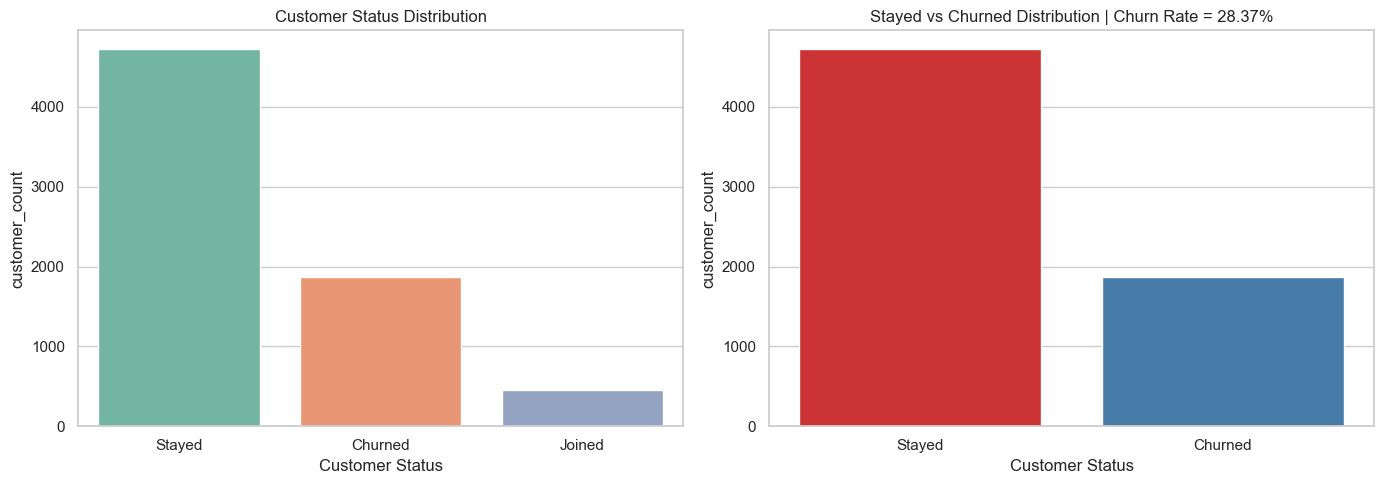

,Customer Status,customer_count
0,Stayed,4720
1,Churned,1869
2,Joined,454


,Customer Status,customer_count
0,Stayed,4720
1,Churned,1869


In [7]:
status_distribution = df["Customer Status"].value_counts(dropna=False).rename_axis("Customer Status").reset_index(name="customer_count")
churn_distribution = analysis_df["Customer Status"].value_counts().rename_axis("Customer Status").reset_index(name="customer_count")
overall_churn_rate = analysis_df["Churn Flag"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=status_distribution, x="Customer Status", y="customer_count", ax=axes[0], palette="Set2")
axes[0].set_title("Customer Status Distribution")

sns.barplot(data=churn_distribution, x="Customer Status", y="customer_count", ax=axes[1], palette="Set1")
axes[1].set_title(f"Stayed vs Churned Distribution | Churn Rate = {overall_churn_rate:.2f}%")

plt.tight_layout()
plt.show()

display(status_distribution)
display(churn_distribution)

## Bivariate / Multivariate AnalysisThe next block compares churned and retained customers across continuous or count-like features. This helps identify whether churn tends to cluster around low tenure, high monthly charge, lower total revenue, or other measurable profiles.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\2553312641.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="Customer Status", y="Tenure in Months", ax=axes[0, 0], palette="coolwarm")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\2553312641.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="Customer Status", y="Monthly Charge", ax=axes[0, 1], palette="viridis")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\2553312641.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, 

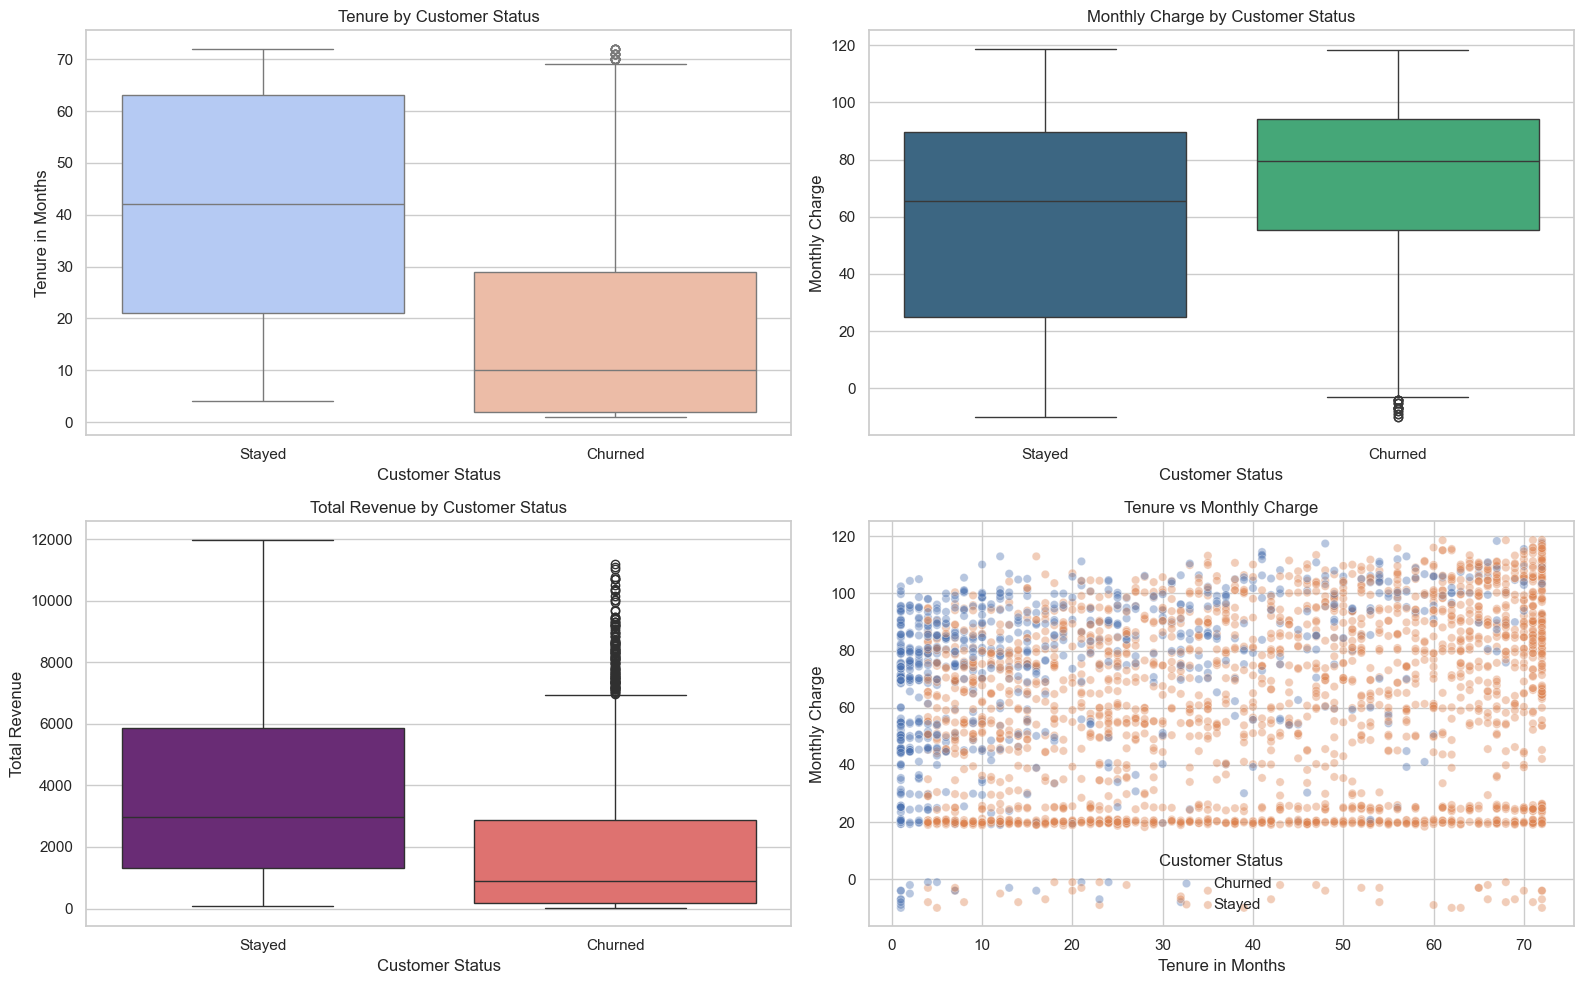

Customer Status,Churned,Stayed
Age,49.735688,45.582415
Tenure in Months,17.979133,41.041525
Monthly Charge,73.347592,61.737415
Total Charges,1531.796094,2788.516831
Total Revenue,1971.353569,3735.676297
Number of Referrals,0.521134,2.614831
Avg Monthly GB Download,23.602506,27.546288


In [8]:
numeric_compare_columns = ["Age", "Tenure in Months", "Monthly Charge", "Total Charges", "Total Revenue", "Number of Referrals", "Avg Monthly GB Download"]
numeric_summary = analysis_df.groupby("Customer Status")[numeric_compare_columns].mean().transpose()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.boxplot(data=analysis_df, x="Customer Status", y="Tenure in Months", ax=axes[0, 0], palette="coolwarm")
axes[0, 0].set_title("Tenure by Customer Status")

sns.boxplot(data=analysis_df, x="Customer Status", y="Monthly Charge", ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Monthly Charge by Customer Status")

sns.boxplot(data=analysis_df, x="Customer Status", y="Total Revenue", ax=axes[1, 0], palette="magma")
axes[1, 0].set_title("Total Revenue by Customer Status")

sns.scatterplot(data=analysis_df.sample(min(len(analysis_df), 3000), random_state=42), x="Tenure in Months", y="Monthly Charge", hue="Customer Status", alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title("Tenure vs Monthly Charge")

plt.tight_layout()
plt.show()

display(numeric_summary)

## Feature-Specific InsightsChurn is often driven by combinations of contract, internet service, support, payment, and billing behavior. This block calculates churn rates across several categorical dimensions so we can see where risk is concentrated.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\342187819.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_risk, x="Contract", y="churn_rate_pct", ax=axes[0, 0], palette="rocket")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\342187819.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet_type_risk, x="Internet Type", y="churn_rate_pct", ax=axes[0, 1], palette="crest")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\342187819.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_method_risk,

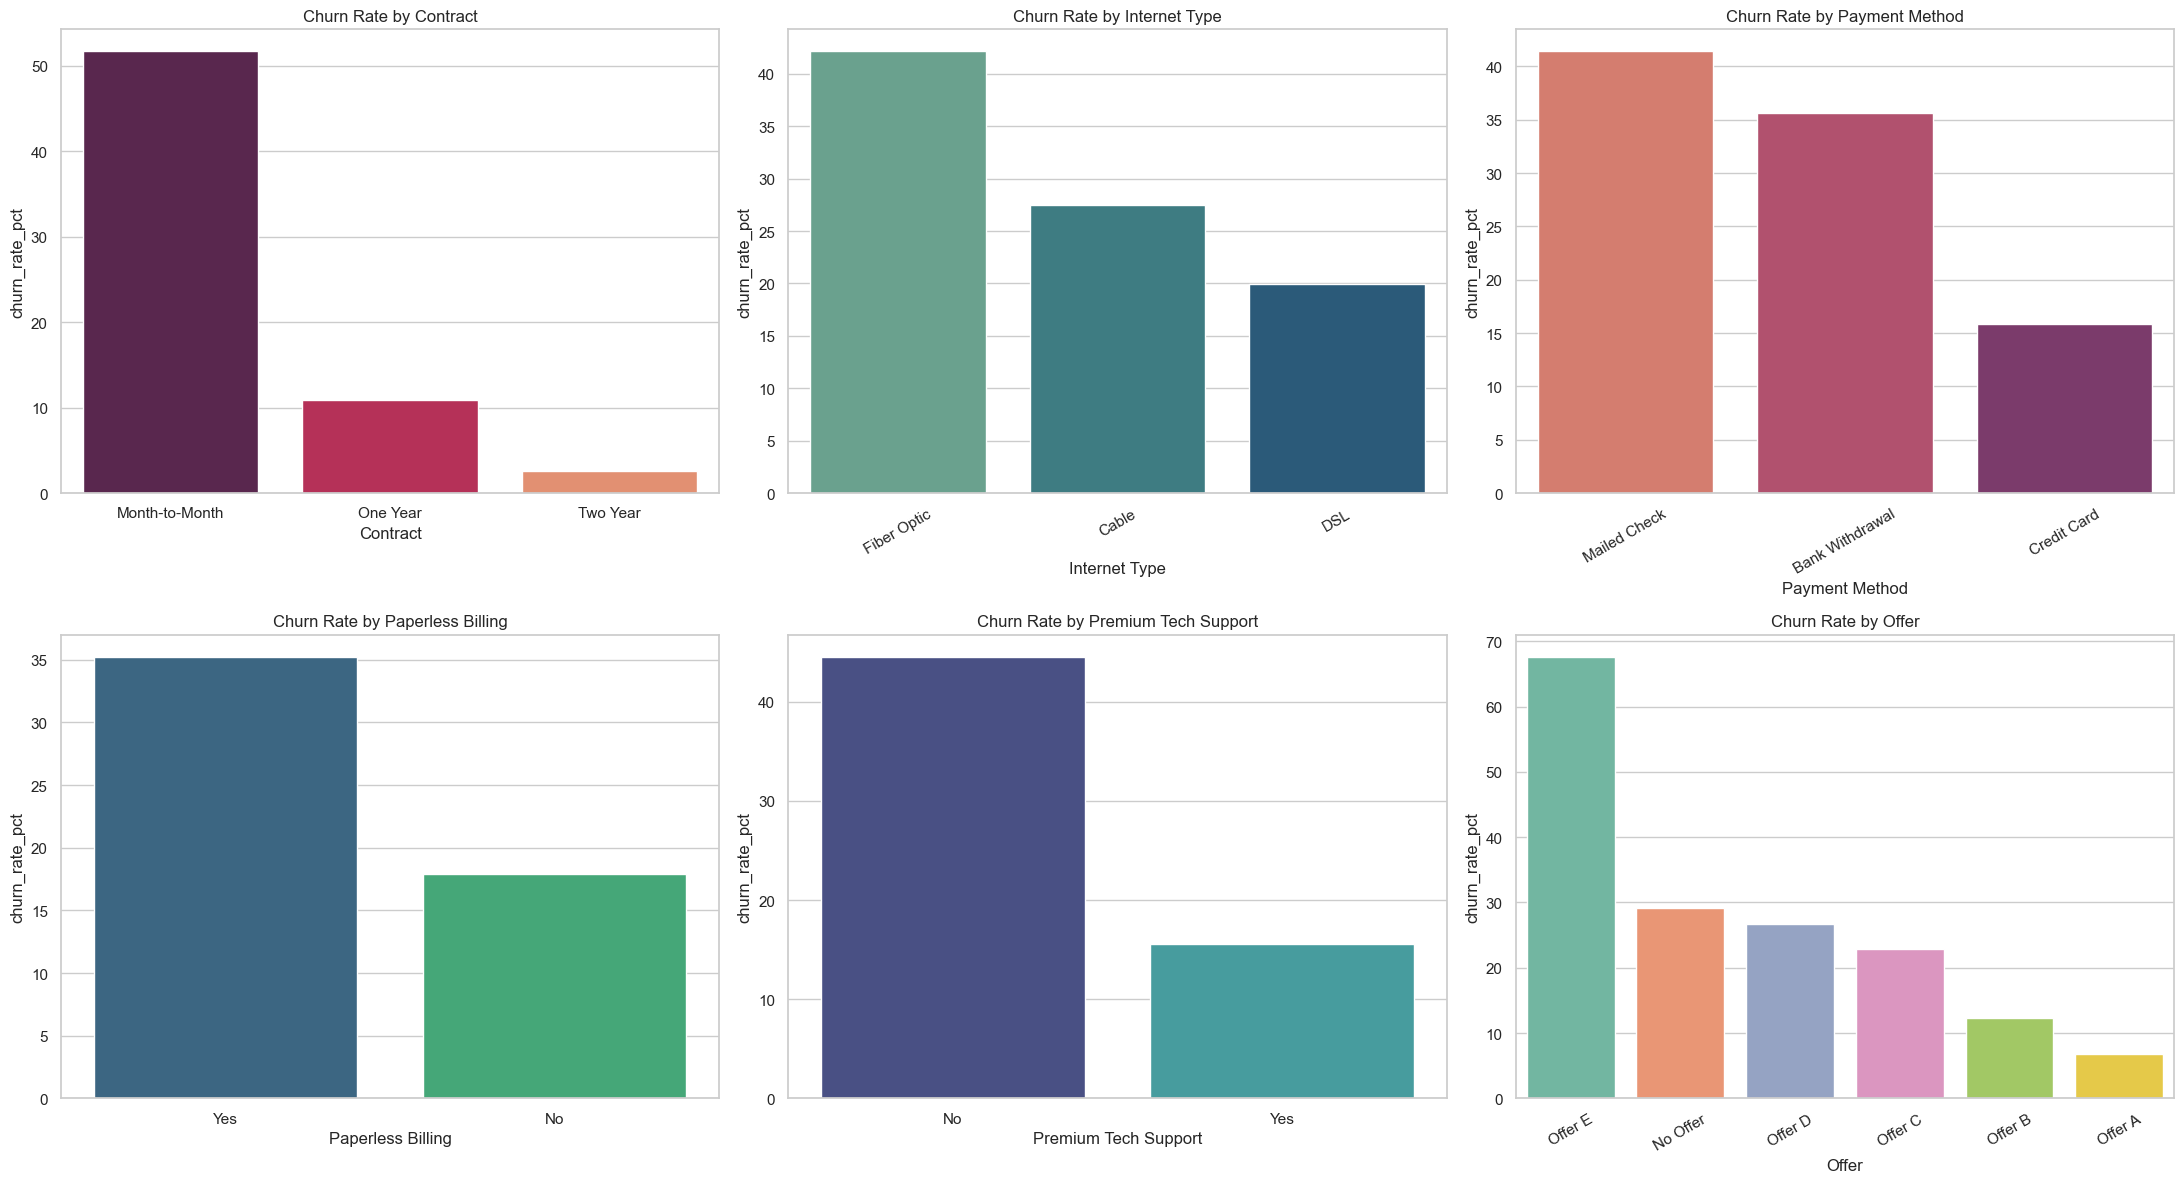

,Contract,customer_count,churn_rate,avg_monthly_charge,avg_total_revenue,churn_rate_pct
0,Month-to-Month,3202,0.516864,67.194394,1909.662236,51.686446
1,One Year,1526,0.108781,64.855439,4042.604751,10.878113
2,Two Year,1861,0.025793,61.451585,4853.895008,2.579258


,Internet Type,customer_count,churn_rate,avg_monthly_charge,avg_total_revenue,churn_rate_pct
2,Fiber Optic,2934,0.421268,90.474864,4221.841738,42.126789
0,Cable,774,0.275194,60.077842,2869.704535,27.519380
1,DSL,1537,0.199740,57.707287,2951.339369,19.973975
3,NaN,1344,0.084077,20.712537,1616.524077,8.407738


,Payment Method,customer_count,churn_rate,avg_monthly_charge,avg_total_revenue,churn_rate_pct
2,Mailed Check,343,0.413994,48.110350,1565.747609,41.399417
0,Bank Withdrawal,3728,0.356491,72.356237,3392.259920,35.649142
1,Credit Card,2518,0.158062,56.489813,3230.125310,15.806195


In [9]:
def churn_rate_table(frame, column_name):
    summary = frame.groupby(column_name, dropna=False).agg(
        customer_count=("Customer ID", "count"),
        churn_rate=("Churn Flag", "mean"),
        avg_monthly_charge=("Monthly Charge", "mean"),
        avg_total_revenue=("Total Revenue", "mean"),
    ).reset_index()
    summary["churn_rate_pct"] = summary["churn_rate"] * 100
    return summary.sort_values(["churn_rate_pct", "customer_count"], ascending=[False, False])

contract_risk = churn_rate_table(analysis_df, "Contract")
internet_type_risk = churn_rate_table(analysis_df, "Internet Type")
payment_method_risk = churn_rate_table(analysis_df, "Payment Method")
paperless_risk = churn_rate_table(analysis_df, "Paperless Billing")
tech_support_risk = churn_rate_table(analysis_df, "Premium Tech Support")
offer_risk = churn_rate_table(analysis_df, "Offer")

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
sns.barplot(data=contract_risk, x="Contract", y="churn_rate_pct", ax=axes[0, 0], palette="rocket")
axes[0, 0].set_title("Churn Rate by Contract")

sns.barplot(data=internet_type_risk, x="Internet Type", y="churn_rate_pct", ax=axes[0, 1], palette="crest")
axes[0, 1].set_title("Churn Rate by Internet Type")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.barplot(data=payment_method_risk, x="Payment Method", y="churn_rate_pct", ax=axes[0, 2], palette="flare")
axes[0, 2].set_title("Churn Rate by Payment Method")
axes[0, 2].tick_params(axis="x", rotation=30)

sns.barplot(data=paperless_risk, x="Paperless Billing", y="churn_rate_pct", ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Churn Rate by Paperless Billing")

sns.barplot(data=tech_support_risk, x="Premium Tech Support", y="churn_rate_pct", ax=axes[1, 1], palette="mako")
axes[1, 1].set_title("Churn Rate by Premium Tech Support")

sns.barplot(data=offer_risk, x="Offer", y="churn_rate_pct", ax=axes[1, 2], palette="Set2")
axes[1, 2].set_title("Churn Rate by Offer")
axes[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

display(contract_risk)
display(internet_type_risk)
display(payment_method_risk)

## Segmentation By Risk Factors
Single-variable views are useful, but churn management usually happens at the segment level. This section combines risk factors to show where churn is concentrated across tenure, age, contract, and internet-service patterns.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\342187819.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = frame.groupby(column_name, dropna=False).agg(
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\342187819.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = frame.groupby(column_name, dropna=False).agg(
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\3826733430.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

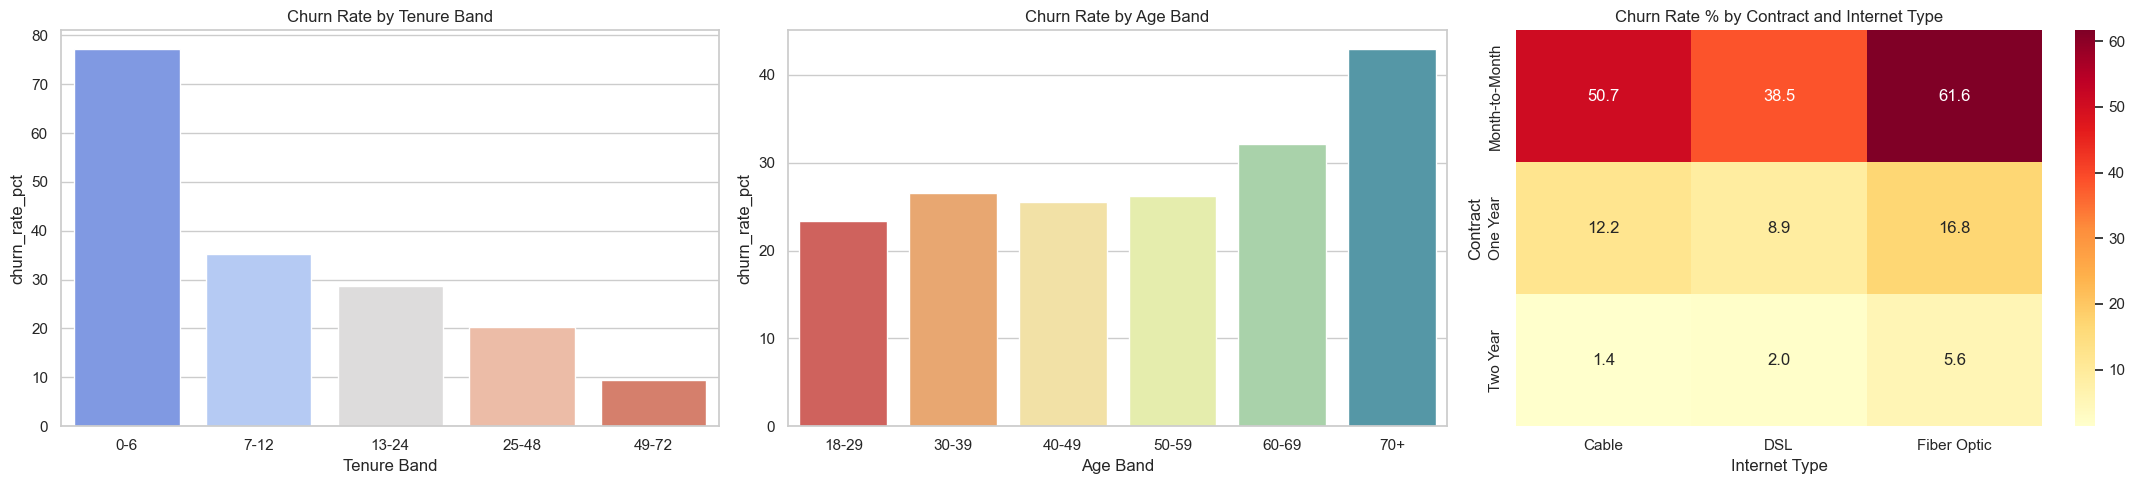

,Tenure Band,Contract,customer_count,churn_rate,avg_monthly_charge,churn_rate_pct
0,0-6,Month-to-Month,959,0.813347,59.666528,81.334724
3,7-12,Month-to-Month,546,0.446886,62.382967,44.688645
6,13-24,Month-to-Month,686,0.405248,67.130394,40.524781
9,25-48,Month-to-Month,715,0.369231,74.194126,36.923077
12,49-72,Month-to-Month,296,0.300676,83.698986,30.067568
13,49-72,One Year,643,0.127527,78.855521,12.752722
10,25-48,One Year,546,0.100733,61.641575,10.073260
7,13-24,One Year,215,0.074419,45.297442,7.441860
14,49-72,Two Year,1300,0.032308,67.386577,3.230769
11,25-48,Two Year,333,0.018018,50.522973,1.801802


In [10]:
tenure_band_risk = churn_rate_table(analysis_df, "Tenure Band")
age_band_risk = churn_rate_table(analysis_df, "Age Band")
contract_internet_heatmap = analysis_df.pivot_table(index="Contract", columns="Internet Type", values="Churn Flag", aggfunc="mean") * 100
tenure_contract_segment = analysis_df.groupby(["Tenure Band", "Contract"], dropna=False).agg(
    customer_count=("Customer ID", "count"),
    churn_rate=("Churn Flag", "mean"),
    avg_monthly_charge=("Monthly Charge", "mean"),
).reset_index()
tenure_contract_segment["churn_rate_pct"] = tenure_contract_segment["churn_rate"] * 100
high_risk_segments = tenure_contract_segment[tenure_contract_segment["customer_count"] >= 100].sort_values("churn_rate_pct", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
sns.barplot(data=tenure_band_risk, x="Tenure Band", y="churn_rate_pct", ax=axes[0], palette="coolwarm")
axes[0].set_title("Churn Rate by Tenure Band")

sns.barplot(data=age_band_risk, x="Age Band", y="churn_rate_pct", ax=axes[1], palette="Spectral")
axes[1].set_title("Churn Rate by Age Band")

sns.heatmap(contract_internet_heatmap, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[2])
axes[2].set_title("Churn Rate % by Contract and Internet Type")

plt.tight_layout()
plt.show()

display(high_risk_segments)

## Statistical ChecksThese tests quantify two common churn questions: whether monthly charges differ between churned and retained customers, and whether churn status is associated with contract type.

In [11]:
from scipy import stats
status_compare = analysis_df[analysis_df['Customer Status'].isin(['Stayed', 'Churned'])].copy()
charge_df = status_compare[['Customer Status', 'Monthly Charge']].dropna()
stayed_charge = charge_df.loc[charge_df['Customer Status'] == 'Stayed', 'Monthly Charge']
churned_charge = charge_df.loc[charge_df['Customer Status'] == 'Churned', 'Monthly Charge']
t_stat, t_p = stats.ttest_ind(churned_charge, stayed_charge, equal_var=False)
contract_table = pd.crosstab(status_compare['Contract'], status_compare['Customer Status'])
chi2_stat, chi2_p, _, _ = stats.chi2_contingency(contract_table)
print(f'T-test on monthly charge (Churned vs Stayed): t={t_stat:.3f}, p={t_p:.2e}')
print(f'Chi-square test of Contract vs Customer Status: chi2={chi2_stat:.3f}, p={chi2_p:.2e}')

T-test on monthly charge (Churned vs Stayed): t=15.092, p=3.83e-50
Chi-square test of Contract vs Customer Status: chi2=1695.694, p=0.00e+00


## Visual AnalysisNot all churn hurts equally. This section looks at revenue patterns and churn reasons together so the business can prioritize the segments that combine high risk with meaningful value at stake.

C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\2881700659.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_status, x="Customer Status", y="avg_total_revenue", ax=axes[0], palette="Set2")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\2881700659.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_at_risk_by_contract, x="Contract", y="estimated_revenue_at_risk", ax=axes[1], palette="rocket")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_35644\2881700659.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

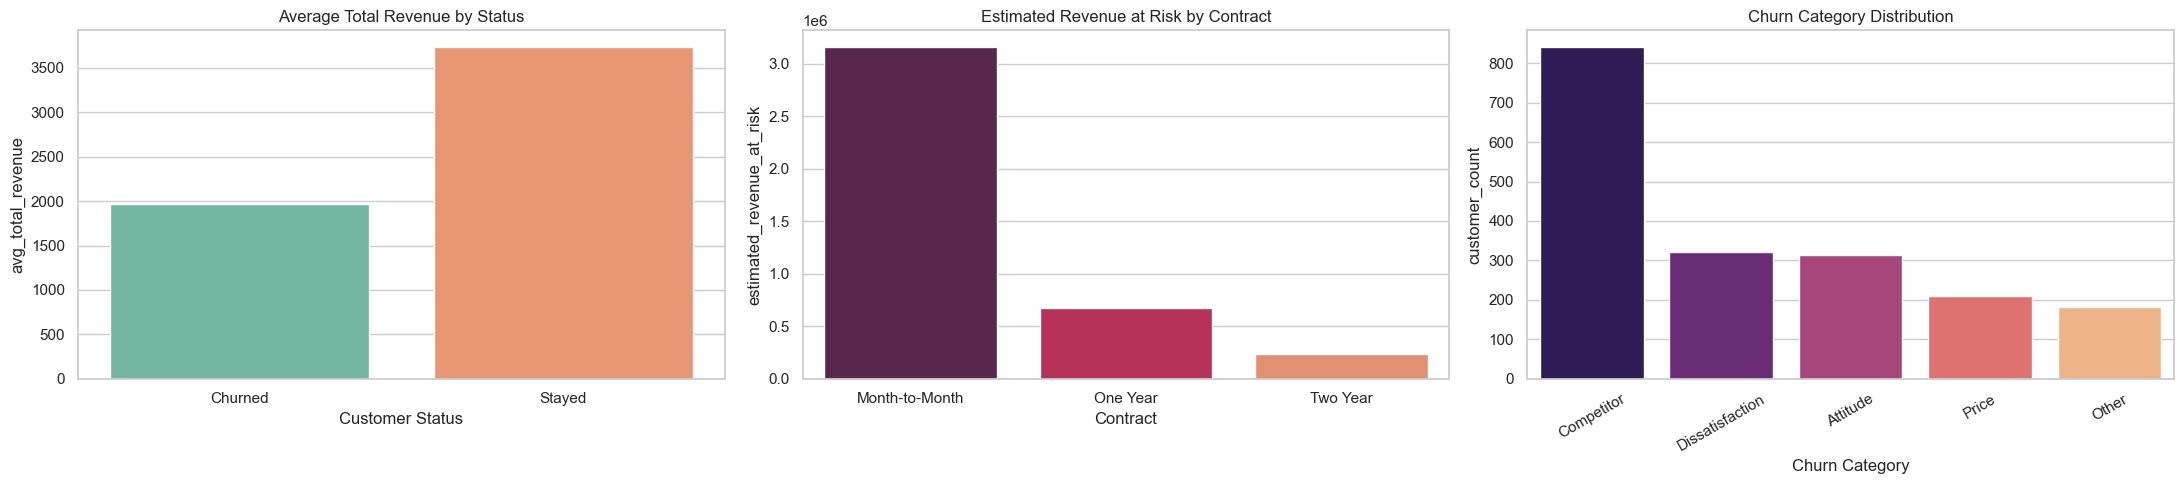

,Customer Status,customer_count,total_revenue,avg_total_revenue,avg_monthly_charge
0,Churned,1869,3684459.82,1971.353569,73.347592
1,Stayed,4720,17632392.12,3735.676297,61.737415


,Contract,customer_count,churn_rate,total_revenue,avg_revenue,estimated_revenue_at_risk
0,Month-to-Month,3202,0.516864,6114738.48,1909.662236,3.160491e+06
1,One Year,1526,0.108781,6169014.85,4042.604751,6.710724e+05
2,Two Year,1861,0.025793,9033098.61,4853.895008,2.329870e+05


,Churn Category,customer_count
0,Competitor,841
1,Dissatisfaction,321
2,Attitude,314
3,Price,211
4,Other,182


,Churn Reason,customer_count
0,Competitor had better devices,313
1,Competitor made better offer,311
2,Attitude of support person,220
3,Don't know,130
4,Competitor offered more data,117
5,Competitor offered higher download speeds,100
6,Attitude of service provider,94
7,Price too high,78
8,Product dissatisfaction,77
9,Network reliability,72


In [12]:
revenue_by_status = analysis_df.groupby("Customer Status", as_index=False).agg(
    customer_count=("Customer ID", "count"),
    total_revenue=("Total Revenue", "sum"),
    avg_total_revenue=("Total Revenue", "mean"),
    avg_monthly_charge=("Monthly Charge", "mean"),
)

revenue_at_risk_by_contract = analysis_df.groupby("Contract", as_index=False).agg(
    customer_count=("Customer ID", "count"),
    churn_rate=("Churn Flag", "mean"),
    total_revenue=("Total Revenue", "sum"),
    avg_revenue=("Total Revenue", "mean"),
)
revenue_at_risk_by_contract["estimated_revenue_at_risk"] = revenue_at_risk_by_contract["churn_rate"] * revenue_at_risk_by_contract["total_revenue"]
revenue_at_risk_by_contract = revenue_at_risk_by_contract.sort_values("estimated_revenue_at_risk", ascending=False)

churned_only = analysis_df[analysis_df["Churn Flag"] == 1].copy()
churn_category_summary = churned_only["Churn Category"].value_counts().rename_axis("Churn Category").reset_index(name="customer_count")
churn_reason_summary = churned_only["Churn Reason"].value_counts().rename_axis("Churn Reason").reset_index(name="customer_count").head(10)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
sns.barplot(data=revenue_by_status, x="Customer Status", y="avg_total_revenue", ax=axes[0], palette="Set2")
axes[0].set_title("Average Total Revenue by Status")

sns.barplot(data=revenue_at_risk_by_contract, x="Contract", y="estimated_revenue_at_risk", ax=axes[1], palette="rocket")
axes[1].set_title("Estimated Revenue at Risk by Contract")

sns.barplot(data=churn_category_summary, x="Churn Category", y="customer_count", ax=axes[2], palette="magma")
axes[2].set_title("Churn Category Distribution")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

display(revenue_by_status)
display(revenue_at_risk_by_contract)
display(churn_category_summary)
display(churn_reason_summary)

## Key FindingsThe next cell summarizes the main findings from the computed tables so the final takeaways stay grounded in the actual analysis results instead of prewritten claims.

In [13]:
highest_risk_contract = contract_risk.iloc[0]
highest_risk_internet = internet_type_risk.iloc[0]
highest_risk_payment = payment_method_risk.iloc[0]
highest_risk_tenure = tenure_band_risk.iloc[0]
top_revenue_risk_contract = revenue_at_risk_by_contract.iloc[0]
top_churn_category = churn_category_summary.iloc[0]
top_churn_reason = churn_reason_summary.iloc[0]

insights = [
    f"Overall churn rate among comparable retained-vs-churned customers is {overall_churn_rate:.2f}%.",
    f"Highest-risk contract type: {highest_risk_contract['Contract']} with churn rate {highest_risk_contract['churn_rate_pct']:.2f}%.",
    f"Highest-risk internet type: {highest_risk_internet['Internet Type']} with churn rate {highest_risk_internet['churn_rate_pct']:.2f}%.",
    f"Highest-risk payment method: {highest_risk_payment['Payment Method']} with churn rate {highest_risk_payment['churn_rate_pct']:.2f}%.",
    f"Highest-risk tenure band: {highest_risk_tenure['Tenure Band']} with churn rate {highest_risk_tenure['churn_rate_pct']:.2f}%.",
    f"Largest estimated contract-level revenue exposure appears in {top_revenue_risk_contract['Contract']}.",
    f"Top churn category among churned customers: {top_churn_category['Churn Category']}.",
    f"Most frequent churn reason in the top-10 breakdown: {top_churn_reason['Churn Reason']}.",
]

for item in insights:
    print(f"- {item}")

- Overall churn rate among comparable retained-vs-churned customers is 28.37%.
- Highest-risk contract type: Month-to-Month with churn rate 51.69%.
- Highest-risk internet type: Fiber Optic with churn rate 42.13%.
- Highest-risk payment method: Mailed Check with churn rate 41.40%.
- Highest-risk tenure band: 0-6 with churn rate 77.17%.
- Largest estimated contract-level revenue exposure appears in Month-to-Month.
- Top churn category among churned customers: Competitor.
- Most frequent churn reason in the top-10 breakdown: Competitor had better devices.


## Recommendations / Next Steps- Prioritize retention for the highest-risk contract and tenure segments first, because these customers combine elevated churn probability with meaningful revenue exposure.
- Review offer strategy for early-tenure customers to reduce fast churn before habits become unstable.
- Target customers with weak support or higher-friction service profiles using proactive outreach, service checks, and product education.
- Reassess payment and billing friction, especially if the riskiest payment method and paperless-billing profile stay elevated after controlling for customer count.
- Use churn category and churn reason summaries to separate competitor-driven churn from dissatisfaction-driven churn, since those require different interventions.

## Limitations
- This is a descriptive analysis, not a causal model, so the notebook identifies associations rather than proven causes.
- Joined customers are intentionally excluded from the main churn-risk comparison, which improves comparability but narrows the scope of the analysis.
- Some operational context, such as campaign history or service outage logs, is not present in the dataset.

## Common Mistakes
- Treating all non-churned customers as equivalent when the dataset contains newly joined customers.
- Ranking risk segments by churn rate alone without checking customer count or revenue exposure.
- Confusing churn reasons with root causes when they may reflect only the final recorded explanation.

## Mini Challenge
1. Compare churn rates within the highest-risk contract type across age bands and tenure bands.
2. Build a simple churn-risk score using the top categorical and numeric signals discovered in this notebook.
3. Re-run the segment analysis using only customers above median total revenue to focus on high-value churn.

## Final Summary / Key Takeaways
This notebook builds a customer-level churn analysis workflow that starts with label hygiene, then moves through churn distribution, numeric and categorical feature relationships, risk segmentation, churn-reason breakdowns, and business recommendations. The core discipline is to analyze comparable customers, look at segment-level risk instead of single features only, and tie retention priorities to both churn probability and revenue exposure.